<a href="https://colab.research.google.com/github/liliannakakaawa/iris-streamlit-app-lilian/blob/main/ml_demo_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OmicsLogic — Mini Machine Learning examples
### From Data Cleaning → EDA → Visualization → Prediction


**What you'll learn:**
| Step | Action | Tool |
|---|---|---|
| 1 | Import ML library | `scikit-learn` |
| 2 | Create dataset | `pandas` |
| 3 | Define features & target | `X` and `y` |
| 4 | Train the model | `model.fit()` |
| 5 | Make predictions | `model.predict()` |
| 6 | Visualize the model | `matplotlib` |
| 7 | Connect to Omics | Gene expression → disease prediction |

---
> 💡 Run each cell with `Shift + Enter`. Read the notes before each block!

---
## 📦 Step 0 — Import All Libraries

We need four libraries for this demo:

| Library | Role |
|---|---|
| `pandas` | Create and manage the dataset |
| `numpy` | Numerical operations |
| `matplotlib` | Plot data and model output |
| `sklearn` | Build and evaluate the ML model |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📊 Step 1 — Create the Dataset

*"We want to predict exam scores based on hours studied. This is called **supervised learning**  we have both input (hours) and output (score) data, and the model learns the relationship between them."*

**Vocabulary:**
- **Feature** (`X`) — the input variable the model uses to predict. Here: hours studied.
- **Target** (`y`) — the output variable we want to predict. Here: exam score.
- **Supervised learning** — learning from labeled examples (we already know the correct answers).

In [ ]:
# --- Create dataset ---
data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8],
    "Score":         [40, 50, 60, 65, 75, 80, 85, 92]
}

df = pd.DataFrame(data)
print(df)
print(f"\nDataset shape: {df.shape}  ({df.shape[0]} students, {df.shape[1]} columns)")

   Hours_Studied  Score
0              1     40
1              2     50
2              3     60
3              4     65
4              5     75
5              6     80
6              7     85
7              8     92

Dataset shape: (8, 2)  (8 students, 2 columns)


In [ ]:
# --- Quick EDA before modeling (always do this!) ---
print("Summary Statistics:")
print(df.describe())

print(f"\nCorrelation between Hours and Score:  {df['Hours_Studied'].corr(df['Score']):.3f}")
# A correlation close to 1.0 means a strong positive relationship

Summary Statistics:
       Hours_Studied      Score
count        8.00000   8.000000
mean         4.50000  68.375000
std          2.44949  17.880057
min          1.00000  40.000000
25%          2.75000  57.500000
50%          4.50000  70.000000
75%          6.25000  81.250000
max          8.00000  92.000000

Correlation between Hours and Score:  0.993


---
##  Step 2 — Define X and y, Split into Train/Test

*"In machine learning, we always split our data into two parts: **training data** (what the model learns from) and **test data** (what we use to check if the model actually works on unseen examples). This prevents the model from just memorizing answers."*

```
Full Dataset
├── Training Set (75%) → model.fit()       → model learns
└── Test Set     (25%) → model.predict()   → we evaluate
```

In [ ]:
# --- Define features (X) and target (y) ---
X = df[["Hours_Studied"]]   # 2D array — required by scikit-learn
y = df["Score"]             # 1D series

print("X (features):")
print(X)
print("\ny (target):")
print(y.values)

X (features):
   Hours_Studied
0              1
1              2
2              3
3              4
4              5
5              6
6              7
7              8

y (target):
[40 50 60 65 75 80 85 92]


In [ ]:
# --- Split into training and test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% goes to test set
    random_state=42      # ensures reproducibility
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 6
Test samples:     2


---
##  Step 3 — Train the Model

 *"Training means the model looks at the data and finds the best-fit straight line that describes the relationship between hours studied and score. It adjusts a slope and intercept to minimize prediction errors."*

**How Linear Regression works:**
```
Predicted Score = (slope × Hours_Studied) + intercept

Example:  Score = 8.5 × Hours + 32.0
```
The model finds the best `slope` and `intercept` automatically from the data.

In [ ]:
# --- Create and train the model ---
model = LinearRegression()
model.fit(X_train, y_train)    # Training happens here

print("✅ Model trained!")
print(f"\nModel equation:")
print(f"  Score = {model.coef_[0]:.2f} × Hours_Studied + {model.intercept_:.2f}")
print(f"\nInterpretation: Each extra hour of studying adds ~{model.coef_[0]:.1f} points.")

✅ Model trained!

Model equation:
  Score = 7.20 × Hours_Studied + 35.90

Interpretation: Each extra hour of studying adds ~7.2 points.


---
## Step 4 — Make Predictions & Evaluate
*"Now we ask the model: given a new number of hours, what score do you predict? We also check how accurate the model is using two metrics."*

**Evaluation Metrics:**
| Metric | What it means | Good value |
|---|---|---|
| **R² Score** | How much variance the model explains (0–1) | Closer to 1.0 |
| **RMSE** | Average error in the same units as the target | Lower is better |

In [ ]:
# --- Predict on test set ---
y_pred = model.predict(X_test)

print("Predictions on test data:")
results = pd.DataFrame({
    "Hours_Studied": X_test["Hours_Studied"].values,
    "Actual_Score":  y_test.values,
    "Predicted_Score": y_pred.round(1)
})
print(results.to_string(index=False))

Predictions on test data:
 Hours_Studied  Actual_Score  Predicted_Score
             2            50             50.3
             6            80             79.1


In [ ]:
# --- Evaluate model accuracy ---
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score:  {r2:.3f}  (model explains {r2*100:.1f}% of the variance)")
print(f"RMSE:      {rmse:.2f} points  (average prediction error)")

R² Score:  0.998  (model explains 99.8% of the variance)
RMSE:      0.67 points  (average prediction error)


In [ ]:
# --- Predict for a new unseen student ---
new_hours = [[7]]
predicted = model.predict(new_hours)

print(f"🎯 If a student studies for 7 hours, predicted score: {predicted[0]:.1f}")

🎯 If a student studies for 7 hours, predicted score: 86.3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
##  Step 5 — Visualize the Model


*"The scatter points are the real student data. The line is what the model learned — it shows how predicted score increases with hours studied. Points close to the line mean accurate predictions."*

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


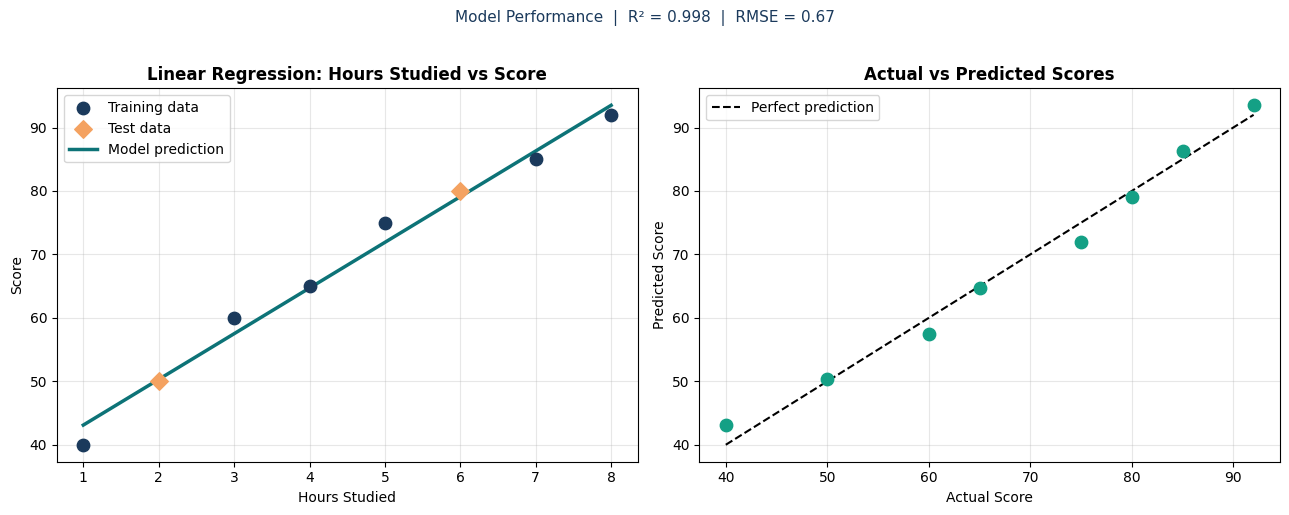

In [ ]:
# --- Visualization: Data + Regression Line ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Regression line ---
ax1 = axes[0]
ax1.scatter(X_train, y_train, color='#1B3A5C', s=80, zorder=3, label='Training data')
ax1.scatter(X_test,  y_test,  color='#F4A261', s=80, zorder=3, label='Test data', marker='D')

# Draw regression line across full range
x_range = np.linspace(X["Hours_Studied"].min(), X["Hours_Studied"].max(), 100).reshape(-1, 1)
ax1.plot(x_range, model.predict(x_range), color='#0D7377', linewidth=2.5, label='Model prediction')

ax1.set_title("Linear Regression: Hours Studied vs Score", fontsize=12, fontweight='bold')
ax1.set_xlabel("Hours Studied")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Actual vs Predicted ---
ax2 = axes[1]
all_pred = model.predict(X)
ax2.scatter(y, all_pred, color='#14A085', s=80, zorder=3)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1.5, label='Perfect prediction')

ax2.set_title("Actual vs Predicted Scores", fontsize=12, fontweight='bold')
ax2.set_xlabel("Actual Score")
ax2.set_ylabel("Predicted Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Model Performance  |  R² = {r2:.3f}  |  RMSE = {rmse:.2f}",
             fontsize=11, color='#1B3A5C', y=1.02)
plt.tight_layout()
plt.show()

---
## 🔄 Step 6 — The Complete ML Pipeline (Summary)
 *"Today you completed the full basic ML pipeline used in real projects. Every step matters — a mistake at data cleaning will break your model no matter how advanced it is."*

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1️⃣  Load Data      →  pd.DataFrame()
 2️⃣  Clean Data     →  fillna(), drop_duplicates()
 3️⃣  Explore (EDA)  →  describe(), value_counts(), corr()
 4️⃣  Visualize      →  plt.scatter(), plt.hist(), plt.boxplot()
 5️⃣  Split Data     →  train_test_split()
 6️⃣  Train Model    →  model.fit(X_train, y_train)
 7️⃣  Predict        →  model.predict(X_test)
 8️⃣  Evaluate       →  r2_score(), mean_squared_error()
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```

In [ ]:
# --- The FULL pipeline in one clean block ---

# 1. Data
df = pd.DataFrame({"Hours_Studied": [1,2,3,4,5,6,7,8], "Score": [40,50,60,65,75,80,85,92]})

# 2. Split
X = df[["Hours_Studied"]]
y = df["Score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Train
model = LinearRegression().fit(X_train, y_train)

# 4. Evaluate
y_pred = model.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.3f}   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 5. Predict new value
print(f"Predicted score for 9 hours: {model.predict([[9]])[0]:.1f}")

R²: 0.998   RMSE: 0.67
Predicted score for 9 hours: 100.7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## Step 7 — Omics Connection: Gene Expression → Disease Prediction

>  *"Instead of predicting exam scores, researchers use the exact same approach to predict disease risk from gene expression. The model structure is identical — only the data changes."*

**The parallel:**

| Study Hours Example | Omics Research Example |
|---|---|
| Hours Studied → Score | Gene Expression → Disease Status |
| 1 feature (hours) | Many features (thousands of genes) |
| Linear Regression | Logistic Regression / Random Forest |
| Exam prediction | Cancer diagnosis / Risk stratification |

---
Let's simulate a tiny version with **3 genes** and **disease status** as the target.

In [ ]:
# --- Synthetic gene expression dataset ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

# Simulate 30 samples: 15 Healthy, 15 Disease
n = 15

healthy = pd.DataFrame({
    "BRCA1":     np.random.normal(7.0, 0.5, n),  # lower expression in healthy
    "TP53":      np.random.normal(6.0, 0.4, n),
    "MYC":       np.random.normal(5.5, 0.6, n),
    "Condition": [0] * n  # 0 = Healthy
})

disease = pd.DataFrame({
    "BRCA1":     np.random.normal(9.5, 0.5, n),  # higher expression in disease
    "TP53":      np.random.normal(8.5, 0.4, n),
    "MYC":       np.random.normal(10.0, 0.6, n),
    "Condition": [1] * n  # 1 = Disease
})

df_omics = pd.concat([healthy, disease], ignore_index=True)
print(df_omics.head(6))
print(f"\nShape: {df_omics.shape}  |  Class counts: {df_omics['Condition'].value_counts().to_dict()}")

      BRCA1      TP53       MYC  Condition
0  7.248357  5.775085  5.138976          0
1  6.930868  5.594868  6.611367          0
2  7.323844  6.125699  5.491902          0
3  7.761515  5.636790  4.865373          0
4  6.882923  5.435079  5.993527          0
5  6.882932  6.586260  4.767494          0

Shape: (30, 4)  |  Class counts: {0: 15, 1: 15}


In [ ]:
# --- Quick EDA: mean expression by condition ---
print("Mean gene expression by condition (0=Healthy, 1=Disease):")
print(df_omics.groupby("Condition")[["BRCA1", "TP53", "MYC"]].mean().round(2))

Mean gene expression by condition (0=Healthy, 1=Disease):
           BRCA1  TP53   MYC
Condition                   
0           7.01  5.85  5.34
1           9.52  8.52  9.99


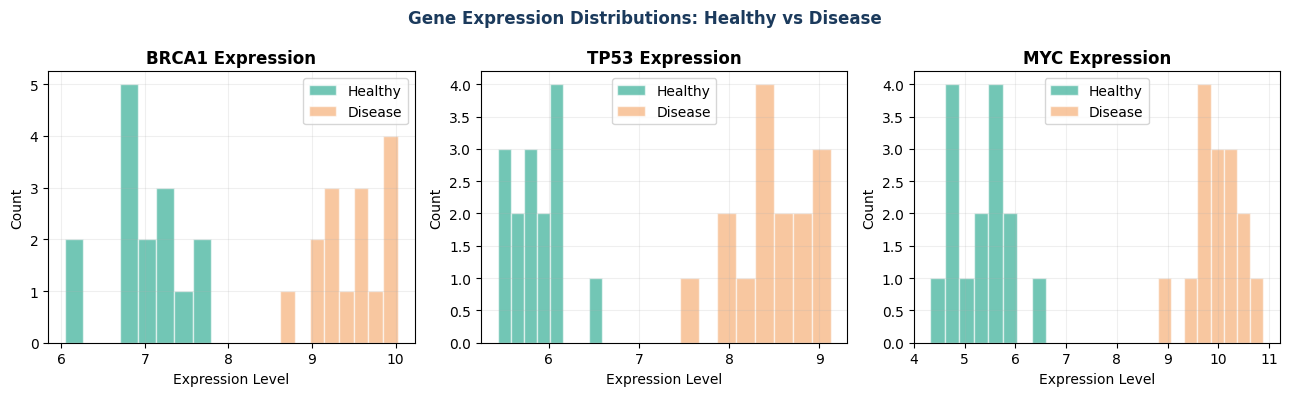

In [ ]:
# --- Visualize gene expression by condition ---
genes = ["BRCA1", "TP53", "MYC"]
colors = {0: '#14A085', 1: '#F4A261'}
labels = {0: 'Healthy', 1: 'Disease'}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, gene in zip(axes, genes):
    for cond in [0, 1]:
        subset = df_omics[df_omics["Condition"] == cond][gene]
        ax.hist(subset, bins=8, alpha=0.6, color=colors[cond], label=labels[cond], edgecolor='white')
    ax.set_title(f"{gene} Expression", fontweight='bold')
    ax.set_xlabel("Expression Level")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.suptitle("Gene Expression Distributions: Healthy vs Disease",
             fontsize=12, fontweight='bold', color='#1B3A5C')
plt.tight_layout()
plt.show()

In [ ]:
# --- Train a Logistic Regression classifier ---
# Same pipeline as before — only model type changes!

X_omics = df_omics[["BRCA1", "TP53", "MYC"]]
y_omics = df_omics["Condition"]

X_tr, X_te, y_tr, y_te = train_test_split(X_omics, y_omics, test_size=0.25, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_tr)

y_pred_omics = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred_omics)

print(f"✅ Model Accuracy: {acc*100:.1f}%")
print()
print("Classification Report:")
print(classification_report(y_te, y_pred_omics, target_names=["Healthy", "Disease"]))

✅ Model Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         2
     Disease       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [ ]:
# --- Predict disease status for a new patient sample ---
new_patient = pd.DataFrame({
    "BRCA1": [9.8],
    "TP53":  [8.7],
    "MYC":   [10.2]
})

prediction  = clf.predict(new_patient)[0]
probability = clf.predict_proba(new_patient)[0]

label = "Disease" if prediction == 1 else "Healthy"
print(f"New patient gene expression:")
print(new_patient.to_string(index=False))
print(f"\n🔬 Model Prediction:  {label}")
print(f"   Confidence — Healthy: {probability[0]*100:.1f}%  |  Disease: {probability[1]*100:.1f}%")

New patient gene expression:
 BRCA1  TP53  MYC
   9.8   8.7 10.2

🔬 Model Prediction:  Disease
   Confidence — Healthy: 1.4%  |  Disease: 98.6%


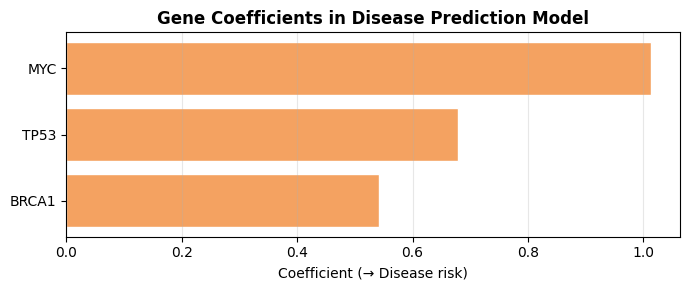

Positive coefficient → higher expression = higher disease risk


In [ ]:
# --- Which gene matters most? (Feature Importance) ---
coef_df = pd.DataFrame({
    "Gene":        ["BRCA1", "TP53", "MYC"],
    "Coefficient": clf.coef_[0]
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(7, 3))
colors = ['#F4A261' if c > 0 else '#14A085' for c in coef_df["Coefficient"]]
plt.barh(coef_df["Gene"], coef_df["Coefficient"], color=colors, edgecolor='white')
plt.axvline(x=0, color='#1B3A5C', linewidth=1.2, linestyle='--')
plt.title("Gene Coefficients in Disease Prediction Model", fontweight='bold')
plt.xlabel("Coefficient (→ Disease risk)")
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Positive coefficient → higher expression = higher disease risk")

---
## Closing — What You Built Today

```
┌─────────────────────────────────────────────────────────┐
│          FULL MACHINE LEARNING PIPELINE                  │
│                                                         │
│  📥 Load Data      →  pd.DataFrame()                    │
│  🧹 Clean Data     →  fillna(), drop_duplicates()       │
│  🔍 Explore (EDA)  →  describe(), corr(), groupby()     │
│  📊 Visualize      →  scatter, hist, boxplot            │
│  ✂️  Split Data     →  train_test_split()               │
│  🏋️  Train Model    →  model.fit(X_train, y_train)      │
│  🔮 Predict        →  model.predict(X_test)             │
│  📏 Evaluate       →  r2_score(), accuracy_score()      │
└─────────────────────────────────────────────────────────┘
```

### The Same Pipeline — Two Different Worlds

| | Study Hours | Omics Research |
|---|---|---|
| **Input (X)** | Hours studied | Gene expression values |
| **Output (y)** | Exam score | Disease status |
| **Model** | Linear Regression | Logistic Regression |
| **Prediction** | Predicted score | Healthy or Disease |
| **Real use** | Learning analytics | Precision medicine, oncology |

---

###  Where to go next
1. **Random Forests** — more powerful classifier for omics data
2. **PCA** — reduce thousands of genes to key components
3. **DESeq2 / edgeR** — differential expression analysis in R
4. **Real datasets** — explore [GEO](https://www.ncbi.nlm.nih.gov/geo/) and [TCGA](https://portal.gdc.cancer.gov/)
5. **OmicsLogic courses** — guided projects with real biological data

---
> 🌐 **OmicsLogic Training Series** — *From raw data to biological insight.*

---
##  Bonus Exercise — Try It Yourself

Use the omics dataset (`df_omics`) to try these tasks:

In [ ]:
# Task 1: Add a 4th gene column called "EGFR" with random values
# Healthy EGFR mean = 5.0, Disease EGFR mean = 8.0, std = 0.5 for both
# Hint: use np.random.normal() and pd.concat()

# Your code here:


In [ ]:
# Task 2: Re-train the Logistic Regression model with EGFR included
# Print the new accuracy — did it improve?

# Your code here:


In [ ]:
# Task 3: Create a boxplot comparing EGFR expression in Healthy vs Disease

# Your code here:
